# Fig2_embedding.ipynb

## Introduction
This notebook computes the correlation between co-occurrence counts and embedding similarities, then calculates average elevations for each species. Finally, it visualizes an embedding space via UMAP, colored by average elevation.

### Download Arial font
`sudo apt update`  
`sudo apt install -y ttf-mscorefonts-installer`  
`sudo fc-cache -f -v`  

### Setting

In [1]:
# Import statements and environment setup
# Additional explanatory comments have been added for clarity.
# The PlotUtlis, create_folder, mm2inch, and set_mpl_defaults are from the associated Utils.py.

from Utils import PlotUtlis, create_folder, mm2inch, set_mpl_defaults
import os
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import umap.umap_ as umap

# Set default plotting parameters (fonts, figure size, etc.)
set_mpl_defaults()

In [2]:
# Define identifiers used for referencing paths in PlotUtlis.
run_id = 'a21e809cf92c477c8e6f67a638adcb03'
exp_id = '560401789505105998'

In [3]:
# Instantiate the PlotUtlis class with run and exp IDs.
# This object manages file paths, data loading, and convenient methods for analysis.
PU = PlotUtlis(run_id = run_id, exp_id = exp_id)

In [4]:
# Create output directories for embedding correlation and dimension reduction plots
# These directories will store generated PDFs and figures.
create_folder(PU.plot_path_embedding_correlation)
create_folder(PU.plot_path_embedding_dimension_reduction)

## Calculatethe relationship betwwen non-environmental species embedding vectors and indices

In [5]:
# Retrieve and filter co-occurrence counts for species in the training list.
species_list_exclude = ['']
species_list = set(PU.species_list_train) - set(species_list_exclude)
coocc_counts = PU.set_cooccurrence_counts(species_list = species_list)

In [8]:
# Build a vector stack for each species, then compute pairwise similarity metrics.

# Initialize an empty vector stack
vec_stack = None

# Concatenate species-specific vectors into vec_stack
for species in PU.species_list_train:
    if vec_stack is None:
        vec_stack = np.array(PU.coocc_vector[species])[None, :]
    else:
        vec_stack = np.concatenate((vec_stack, np.array(PU.coocc_vector[species])[None, :]))

# Compute cosine similarity and Euclidean distance matrices
cos_similarity_matrix = cosine_similarity(vec_stack, vec_stack)
euclidean_distances_matrix = euclidean_distances(vec_stack, vec_stack)

# For each row in coocc_counts, map sp1 and sp2 to the appropriate matrix values.
cos_similarity_list = []
euclidean_dist_list = []
for i, data in coocc_counts.iterrows():
    cos_similarity_list.append(
        cos_similarity_matrix[
            PU.species_list_train.index(data.sp1), 
            PU.species_list_train.index(data.sp2)
        ]
    )
    euclidean_dist_list.append(
        euclidean_distances_matrix[
            PU.species_list_train.index(data.sp1), 
            PU.species_list_train.index(data.sp2)
        ]
    )

# Assign computed similarity and distance to coocc_counts DataFrame.
coocc_counts['cosine_similarity'] = cos_similarity_list
coocc_counts['euclidean_distance'] = euclidean_dist_list

In [9]:
coocc_counts

,sp1,sp2,counts,cosine_similarity,euclidean_distance
0,Abies_kawakamii,Acer_caudatifolium,28,0.170718,1.451807
1,Abies_kawakamii,Acer_morrisonense,39,0.252280,1.400562
2,Abies_kawakamii,Acer_serrulatum,4,-0.175802,1.570792
3,Abies_kawakamii,Actinidia_setosa,2,0.054864,1.506674
4,Abies_kawakamii,Adenophora_morrisonensis_subsp._uehatae,88,0.566125,1.208436
...,...,...,...,...,...
482778,Zehneria_mucronata,Zelkova_serrata,33,0.259928,1.956823
482779,Zehneria_mucronata,Zeuxine_nervosa,26,0.232756,1.948323
482780,Zehneria_mucronata,Zingiber_pleiostachyum,114,0.453735,1.675763
482781,Zelkova_serrata,Zingiber_pleiostachyum,38,0.156465,2.083303


## Plotting

0.6365304662426906 0.0


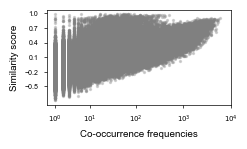

In [14]:
# Calculate the Spearman correlation between co-occurrence counts and cosine similarity
rho, p = scipy.stats.spearmanr(coocc_counts.counts, coocc_counts.cosine_similarity)
print(rho, p)

# Create a scatter plot showing how similarity changes with co-occurrence counts.
fig, ax = plt.subplots(figsize = mm2inch(60, 35), constrained_layout = True)
ax.scatter(
    x = np.log10(coocc_counts.counts + 1),
    y = coocc_counts.cosine_similarity,
    alpha = 0.3,
    color = 'grey',
    s = 2
)
ax.set_ylabel('Similarity score')
ax.set_xlabel('Co-occurrence frequencies')

# Configure x-axis ticks to be powers of 10.
ticks = [1, 10, 100, 1000, 10000]
ax.set_xticks(np.log10(np.array(ticks) + 1))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"$10^{{{int(x)}}}$"))
ax.set_yticks([-0.5, -0.2, 0.1, 0.4, 0.7, 1.0])

# Save figure to the specified path
plot_output = os.path.join(PU.plot_path_embedding_correlation, 'scatter_cosinesimilarity.pdf')
fig.savefig(plot_output, dpi = 500, transparent = True)
fig.savefig(os.path.join(PU.plot_path_embedding_correlation, 'scatter_cosinesimilarity.png'), dpi = 500, transparent = True)

-0.5401682361114668 0.0


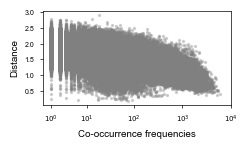

In [15]:
# Calculate the Spearman correlation between co-occurrence counts and Euclidean distance
rho, p = scipy.stats.spearmanr(coocc_counts.counts, coocc_counts.euclidean_distance)
print(rho, p)

# Scatter plot for Euclidean distance vs. co-occurrence counts
fig, ax = plt.subplots(figsize = mm2inch(60, 35), constrained_layout = True)
ax.scatter(
    x = np.log10(coocc_counts.counts + 1),
    y = coocc_counts.euclidean_distance,
    alpha = 0.3,
    color = 'grey',
    s = 2
)
ax.set_ylabel('Distance')
ax.set_xlabel('Co-occurrence frequencies')

# Configure x-axis with powers of 10
ticks = [1, 10, 100, 1000, 10000]
ax.set_xticks(np.log10(np.array(ticks) + 1))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"$10^{{{int(x)}}}$"))

# Export the figure.
plot_output = os.path.join(PU.plot_path_embedding_correlation, 'scatter_euclideandistance.pdf')
fig.savefig(plot_output, dpi=500, transparent=True)
fig.savefig(os.path.join(PU.plot_path_embedding_correlation, 'scatter_euclideandistance.png'), dpi=500, transparent=True)

## Calculate the rank between two selected species

In [ ]:
sp1 = 'Psilopogon_nuchalis'
sp2 = 'Hypsipetes_leucocephalus'

In [ ]:
coocc_counts_sp1 = coocc_counts[(coocc_counts.sp1 == sp1) | (coocc_counts.sp2 == sp1)]
coocc_counts_sp2 = coocc_counts[(coocc_counts.sp1 == sp2) | (coocc_counts.sp2 == sp2)]

coocc_counts_sp12 = coocc_counts[(coocc_counts.sp1 == sp1) & (coocc_counts.sp2 == sp2)]
coocc_counts_sp12 = coocc_counts_sp12 if len(coocc_counts_sp12) != 0 else coocc_counts[(coocc_counts.sp2 == sp1) & (coocc_counts.sp1 == sp2)]

In [ ]:
from scipy import stats
percentile_in_sp1 = stats.percentileofscore(coocc_counts_sp1.euclidean_distance, coocc_counts_sp12.euclidean_distance, kind = 'weak')
percentile_in_sp2 = stats.percentileofscore(coocc_counts_sp2.euclidean_distance, coocc_counts_sp12.euclidean_distance, kind = 'weak')
percentile_in_all = stats.percentileofscore(coocc_counts.euclidean_distance, coocc_counts_sp12.euclidean_distance, kind = 'weak')
print(f'Euclidean distance between {sp1} and {sp2} is {coocc_counts_sp12.euclidean_distance.values[0]:.3f}')
print(f'Percentile of the distance among {sp1} is {percentile_in_sp1[0]:.3f}')
print(f'Percentile of the distance among {sp2} is {percentile_in_sp2[0]:.3f}')
print(f'Percentile of the distance among all residential species is {percentile_in_all[0]:.3f}')

## Calculate average elevation of every species

In [12]:
# Compute and save average elevation for each species.
avg_elevation_df = PU.calculate_avg_elev()
avg_elevation_df.to_csv(PU.avg_elev_path, index = None)
print(f'Average elevation data been saved in {PU.avg_elev_path}')

Average elevation data been saved in plots/a21e809cf92c477c8e6f67a638adcb03/Fig2_embedding_dimension_reduction/avg_elevation.csv


## Plotting non-environmental species embedding vector based on average elevation

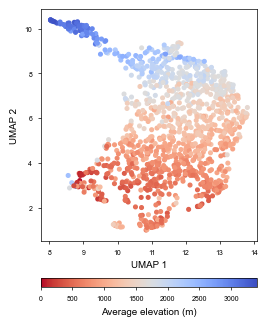

In [16]:
# Perform UMAP on co-occurrence embedding vectors, then color by average elevation.

# Optional loading of average_elevation_df if needed.
# avg_elevation_df = pd.read_csv(PU.avg_elev_path)

# Construct the data matrix of co-occurrence vectors.
df_vec = pd.DataFrame([
    PU.coocc_vector[species]
    for species in PU.species_list_train
])

# Set up UMAP with chosen parameters (neighbors, components, random state)
reducer = umap.UMAP(n_neighbors = 22, n_components=2, random_state=42, n_jobs=1)
embedding_umap = reducer.fit_transform(df_vec.values)

# Create figure with two axes: the main plot, plus a colorbar axis.
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=mm2inch(65, 80), height_ratios=(25, 1), constrained_layout=True
)

# Retrieve the average elevation for each species in the same order.
elev_values = [
    avg_elevation_df[avg_elevation_df.Species == sp].AverageElevation.values.tolist()[0]
    for sp in PU.species_list_train
]

# Convert UMAP embedding to a NumPy array.
umap_values = [embedding_umap[i] for i, sp in enumerate(PU.species_list_train)]
umap_values = np.array(umap_values)

# Scatter plot: X=UMAP dimension 1, Y=UMAP dimension 2, color by average elevation.
ax_scatter = ax1.scatter(
    umap_values[:, 0],
    umap_values[:, 1],
    c=elev_values,
    cmap='coolwarm_r',
    s=7,
    vmin=0
)

# Label axes.
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')

# Create a horizontal colorbar below the main plot.
cbar = fig.colorbar(ax_scatter, ax=ax2, orientation='horizontal', cax=ax2)
cbar.set_label('Average elevation (m)')

# Save the figure as a PDF.
plot_output = os.path.join(PU.plot_path_embedding_dimension_reduction, 'embedding_umap_elev.pdf')
plt.savefig(plot_output, dpi=200, transparent=True)
plt.savefig(os.path.join(PU.plot_path_embedding_dimension_reduction, 'embedding_umap_elev.png'), dpi=500, transparent=True)

# Display the final plot.
plt.show()